In [1]:
import logging
import os

In [2]:
logging.basicConfig(level=logging.INFO)

In [3]:
import galsim
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from chromatic_weak_lensing import SimpleStar

In [5]:
bands = {"u", "g", "r", "i", "z", "y"}
bandpasses = {
    band: galsim.Bandpass(f"LSST_{band}.dat", "nm").withZeropoint("AB")
    for band in bands
}

In [6]:
simple_star = SimpleStar()

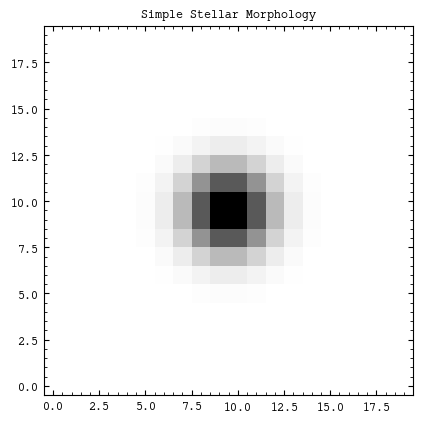

In [7]:
fig, axs = plt.subplots(1, 1)

axs.set_title("Simple Stellar Morphology")

morph = simple_star.get_morphology()

psf = galsim.Gaussian(fwhm=0.7)
observed = galsim.Convolve([psf, morph])
image = observed.drawImage(scale=0.2)

axs.imshow(image.array, origin="lower")

plt.show()

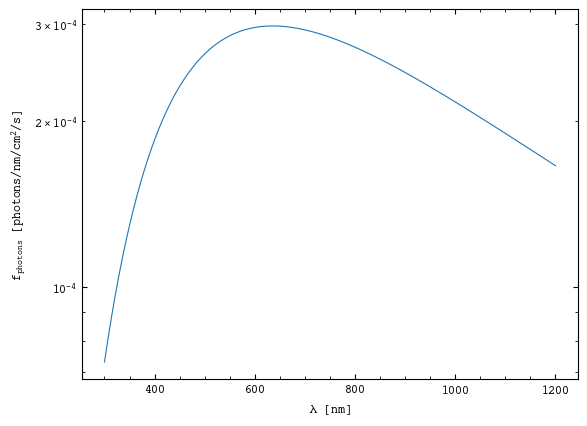

In [8]:
fig, axs = plt.subplots(1, 1)

axs.set_yscale("log")
axs.set_xlabel("$\lambda$ [$nm$]")
axs.set_ylabel("$f_{photons}$ [$photons/nm/cm^2/s$]")

wl = np.linspace(300, 1200, 1000)

spec = simple_star.get_spectrum()

axs.plot(wl, spec(wl))

plt.show()

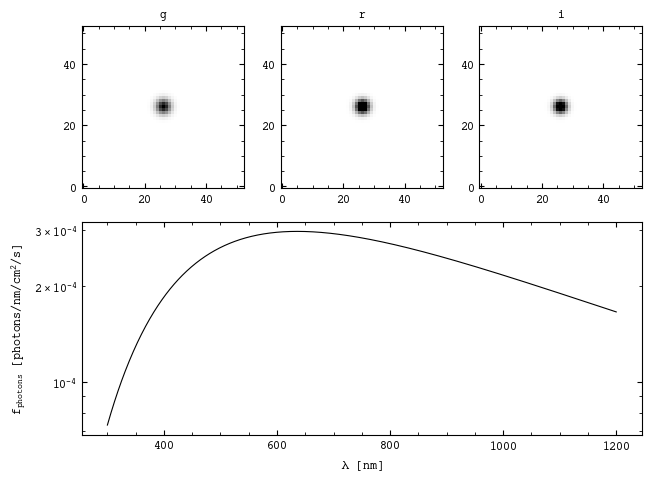

In [9]:
fig, axs = plt.subplot_mosaic(
    [
        ["g", "r", "i"],
        ["sed", "sed", "sed"]
    ],
    constrained_layout=True,
)

axs["sed"].set_yscale("log")
axs["sed"].set_xlabel("$\lambda$ [$nm$]")
axs["sed"].set_ylabel("$f_{photons}$ [$photons/nm/cm^2/s$]")

axs["g"].set_title("g")
axs["r"].set_title("r")
axs["i"].set_title("i")

wl = np.linspace(300, 1200, 1000)

i = -1

star = simple_star.get_star()

base_psf = galsim.Gaussian(fwhm=0.7)
psf = galsim.ChromaticAtmosphere(
    base_psf,
    700,
    alpha=-0.3,
    zenith_angle=0 * galsim.degrees,
    parallactic_angle=0 * galsim.degrees,
)

observed = galsim.Convolve([psf, star])
g_image = observed.drawImage(nx=53, ny=53, scale=0.2, bandpass=bandpasses["g"])
r_image = observed.drawImage(nx=53, ny=53, scale=0.2, bandpass=bandpasses["r"])
i_image = observed.drawImage(nx=53, ny=53, scale=0.2, bandpass=bandpasses["i"])

norm = mpl.colors.Normalize()

axs["sed"].plot(wl, star.sed(wl), c="k")
axs["g"].imshow(g_image.array, norm=norm, origin="lower")
axs["r"].imshow(r_image.array, norm=norm, origin="lower")
axs["i"].imshow(i_image.array, norm=norm, origin="lower")

plt.show()